### Required Libraries

In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from xgboost import plot_importance
from matplotlib import pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score,precision_score,roc_auc_score,accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.svm import SVC
import seaborn as sns
import numpy as np
import operator
import glob
import os
from ctgan import CTGAN
from sdmetrics.reports.single_table import QualityReport
from imblearn.over_sampling import SMOTE


In [ ]:
#! pip install ctgan
#! pip install sdmetrics

In [ ]:
# Our function to load our csv file
def load_dataset(folder):
  files = glob.glob(folder+"/*.csv")
  df_list = []
  df = None
  for file in files:
    df = pd.read_csv(file)
    #df['source_file'] = os.path.basename(file)
    df_list.append(df)

  if len(df_list) == 1:
    return df
  else:
    return pd.concat([df_list],ignore_index=True).sample(frac=1).reset_index(drop=True)


In [ ]:
!unzip "/content/archive.zip" -d "/content/datasets"

Archive:  /content/archive.zip
  inflating: /content/datasets/creditcard.csv  


In [ ]:
# Our first datasets
credit_df = load_dataset("/content/datasets")

In [ ]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Check if we have null values
credit_df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
def xgb_recall(preds, dtrain):
    labels = dtrain.get_label()
    return 'recall',  recall_score(labels, np.round(preds))

def xgb_precision(preds, dtrain):
    labels = dtrain.get_label()
    return 'precision',  precision_score(labels, np.round(preds))


def xgb_roc_auc(preds, dtrain):
    labels = dtrain.get_label()
    return 'roc_auc',  roc_auc_score(labels, preds)

In [ ]:
# Defining our function to train xgb_model
def train_xgboost(xgb_params,ds_train,ds_test):
  result_dict = {}
  xgb_model = xgb.train(
      xgb_params, ds_train, num_boost_round=100,
      verbose_eval=False,
      early_stopping_rounds=30,
      evals=[(ds_train, 'train'), (ds_test, 'test')],
      evals_result=result_dict,
      #feval=xgb_recall, maximize=True
  )

  return xgb_model,result_dict



In [ ]:
def plot_xgb_training_curve(results_dict,xgb_model):
  for i in results_dict:
    for err in results_dict[i]:
      plt.plot(results_dict[i][err], label=i+' '+err)

  plt.axvline(xgb_model.best_iteration, c='green', label='best iteration')
  plt.xlabel('iteration')
  # plt.ylabel(err)
  plt.title('xgboost learning curves')
  plt.legend()
  plt.grid()

In [ ]:
def xgbplot_feature_importance(xgb_model):
  fig,ax = plt.subplots(1,1,figsize=(8,8))
  xgb.plot_importance(xgb_model,max_num_features=10,height=0.5,ax=ax,color='#B71C1C')

In [ ]:
def convert_time_of_day_to_hour(time_seconde):
  return (time_seconde/3600) % 24

In [ ]:
def plot_frequency_distribution(df,column,xlabel,ylabel,title,names = ['Normal','Fraud']):
  plt.figure(figsize=(6,4))
  x1 = df.loc[df.Class == 0, column]
  x2 = df.loc[df.Class == 1, column]
  colors = ['#1B5E20','#B71C1C']
  names = names
  ax = plt.hist([x1,x2], color=colors, label=names,density=True,bins=np.linspace(0,24,25))
  plt.legend()
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.title(title)
  plt.show()

In [ ]:
def kde_plot_frequency(df,column,xlabel,ylabel,title,names = ['Normal','Fraud']):
  plt.figure(figsize=(6,4))
  x1 = df.loc[df.Class == 0, column]
  x2 = df.loc[df.Class == 1, column]
  transactions = [x1,x2]
  sns.displot(df,kind="kde",x=column,hue='Class',common_norm=False,linewidth=2,
  palette=['#1B5E20','#B71C1C'],legend=False)
  plt.legend(names,title='Transactions')
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.show()

In [ ]:
class BaseGAN(nn.Module):

  def __init__(self,feature_dim,latent_dim=128,hidden_dims=(256, 512, 1024)):

      super().__init__()

      self.feature_dim = feature_dim
      self.latent_dim = latent_dim

      self.generator = nn.Sequential(

          nn.Linear(latent_dim, hidden_dims[0]),
          nn.BatchNorm1d(hidden_dims[0]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[0], hidden_dims[1]),
          nn.BatchNorm1d(hidden_dims[1]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[1], hidden_dims[2]),
          nn.BatchNorm1d(hidden_dims[2]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[2], feature_dim) )

      self.critic = nn.Sequential(

          nn.Linear(feature_dim, hidden_dims[2]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[2], hidden_dims[1]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[1], hidden_dims[0]),
          nn.LeakyReLU(0.2, inplace=True),

          nn.Linear(hidden_dims[0], 1)

      )


  def generate(self, z):
    return self.generator(z)


  def discriminate(self, x):
    return self.critic(x)

  def sample_noise(self, batch_size, device):
    return torch.randn(batch_size,self.latent_dim, device=device)

  def gradient_penalty(self,real_samples,fake_samples,device):

    batch_size = real_samples.size(0)
    epsilon = torch.rand(
          batch_size,
          1,
          device=device
      )

    epsilon = epsilon.expand_as(real_samples)

    interpolated = (
          epsilon * real_samples +
          (1 - epsilon) * fake_samples
      )

    interpolated.requires_grad_(True)

    mixed_scores = self.discriminate(
          interpolated
      )

    gradients = torch.autograd.grad(
          outputs=mixed_scores,
          inputs=interpolated,
          grad_outputs=torch.ones_like(
              mixed_scores
          ),
          create_graph=True,
          retain_graph=True
      )[0]

    gradients = gradients.view(
          batch_size,
          -1
      )

    gradient_norm = gradients.norm(
          2,
          dim=1
      )

    gp = (
          (gradient_norm - 1) ** 2
      ).mean()

    return gp

In [ ]:
def train_critic(model,real_batch,optimizer,lambda_gp,device):

  batch_size = real_batch.size(0)
  z = model.sample_noise(
          batch_size,
          device
      )

  fake_batch = model.generate(z)

  critic_real = model.discriminate(
          real_batch
      ).mean()

  critic_fake = model.discriminate(fake_batch.detach()).mean()

  gp = model.gradient_penalty(real_batch,fake_batch.detach(),device)

  loss = (
          -critic_real +
          critic_fake +
          lambda_gp * gp
      )

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  return loss.item()

In [ ]:
def train_generator(model,optimizer,batch_size,device):
  z = model.sample_noise(batch_size,device)
  fake_batch = model.generate(z)
  loss = -model.discriminate(fake_batch).mean()
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  return loss.item()

In [ ]:
def gan_full_train_loop(model,c_optimizer,epochs,lambda_gp,critic_iter,device,train_loader):

  for epoch in range(epochs):

    for real_batch in train_loader:

      real_batch = real_batch[0].to(device)

      for _ in range(critic_iter):
        critic_loss = train_critic(model,real_batch,c_optimizer,lambda_gp,device)
        generator_loss = train_generator(model,g_optimizer,real_batch.size(0),device)


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Critic: {critic_loss:.4f} "
        f"Generator: {generator_loss:.4f}"
    )


In [ ]:
def plot_tsne_visualization(y_combined,x_tsne,figsize=(12,10)):

  plt.figure(figsize=figsize)
  normal_idx = y_combined == "Normal"
  fraud_idx = y_combined == "Fraud"
  synthetic_idx = y_combined == "Synthetic Fraud"

  plt.scatter(
    x_tsne[normal_idx,0],
    x_tsne[normal_idx,1],
    alpha=0.1,
    s=10,
    label="Normal"
)

  plt.scatter(
      x_tsne[fraud_idx,0],
      x_tsne[fraud_idx,1],
      alpha=0.9,
      s=40,
      label="Real Fraud"
  )

  plt.scatter(
      x_tsne[synthetic_idx,0],
      x_tsne[synthetic_idx,1],
      alpha=0.9,
      s=40,
      marker="x",
      label="Synthetic Fraud"
  )

  plt.legend()
  plt.title("WGAN-GP Fraud Generation Quality")
  plt.show()


In [ ]:
# Check if we have some duplicates in our  dataframe
normal_duplicates = sum(credit_df.loc[credit_df.Class == 0].duplicated())
fraude_duplicates = sum(credit_df.loc[credit_df.Class == 1].duplicated())
total_duplicates = normal_duplicates + fraude_duplicates

print("Normal_duplicates: ",normal_duplicates)
print("Fraud_duplicates: ",fraude_duplicates)
print("total_duplicates: ",total_duplicates)
print("Fraction_duplicates: ",total_duplicates/len(credit_df))

Normal_duplicates:  1062
Fraud_duplicates:  19
total_duplicates:  1081
Fraction_duplicates:  0.00379555277784605


# Remove all duplicates by only keeping one occurence


In [ ]:
credit_df.shape

(284807, 31)

In [ ]:
credit_df = credit_df.drop_duplicates(keep=False)

In [ ]:
# Number of columns
len(credit_df.columns)

31

In [ ]:
# Show data distribution by class
credit_df.groupby("Class")["Class"].count()

,Class
Class,
0,282493
1,460


### showing the frequency of each category

/tmp/ipykernel_7587/1096381447.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=mapped_class,palette=custom_colors)


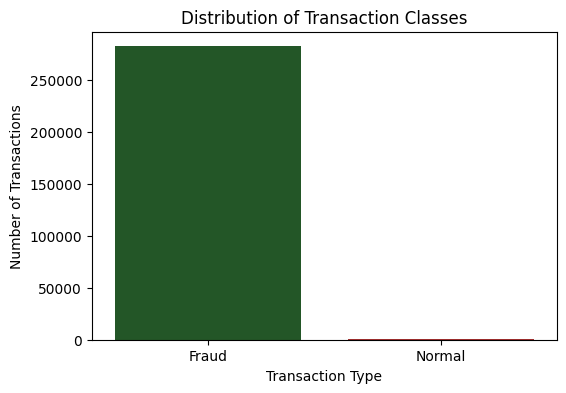

In [ ]:
plt.figure(figsize=(6,4))
label_mapping = {0:"Fraud",1:"Normal"}
custom_colors = ['#1B5E20', '#B71C1C']
mapped_class = credit_df['Class'].map(label_mapping)
sns.countplot(x=mapped_class,palette=custom_colors)
plt.title("Distribution of Transaction Classes")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

### XGBoost evaluation on our unbalanced dataset

In [ ]:
credit_df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
x = credit_df.iloc[:,:-1]
y = credit_df["Class"]

x_train_temp,x_test,y_train_temp,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train_temp,y_train_temp,test_size=0.1,stratify=y_train_temp,random_state=42)

In [ ]:
ds_train = xgb.DMatrix(x_train,y_train,feature_names=x_train.columns.tolist())
ds_val = xgb.DMatrix(x_val,y_val,feature_names=x_val.columns.tolist())
ds_test = xgb.DMatrix(x_test,y_test,feature_names=x_test.columns.tolist())


In [ ]:
# Training our xgb model on unbalanced dataset
xgb_params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.01,
    'max_depth': 4,
    'n_estimators': 100,
    'random_state': 42,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

In [ ]:
xgb_model,result_dict = train_xgboost(xgb_params,ds_train,ds_val)

/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [20:13:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.

  self.starting_round = model.num_boosted_rounds()


In [ ]:
# XGBoost model evaluation on unbalanced dataset
y_pred = xgb_model.predict(ds_test, iteration_range=(0, xgb_model.best_iteration + 1))
y_true = y_test.values
print('best iteration: ', xgb_model.best_iteration)
print(xgb_recall(y_pred, ds_test))
print(xgb_precision(y_pred, ds_test))
print(xgb_roc_auc(y_pred, ds_test))
print("accuracy: ",accuracy_score(y_true,np.round(y_pred)))

best iteration:  99
('recall', 0.6521739130434783)
('precision', 0.9523809523809523)
('roc_auc', np.float64(0.9895463713478576))
accuracy:  0.9993815270979485


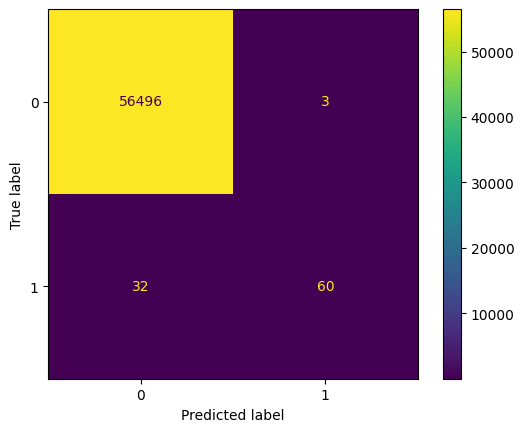

In [ ]:
cm = confusion_matrix(y_true, np.round(y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

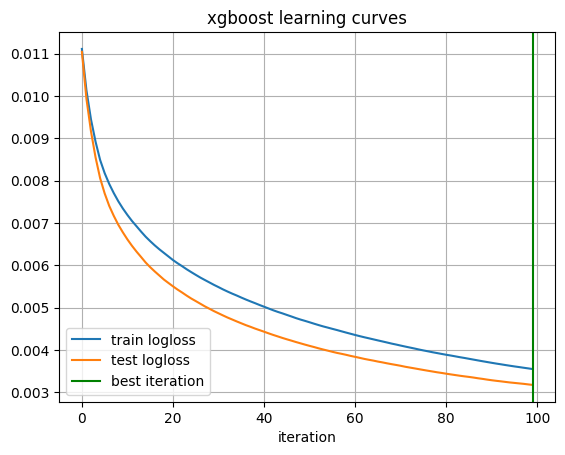

In [ ]:
plot_xgb_training_curve(result_dict,xgb_model)

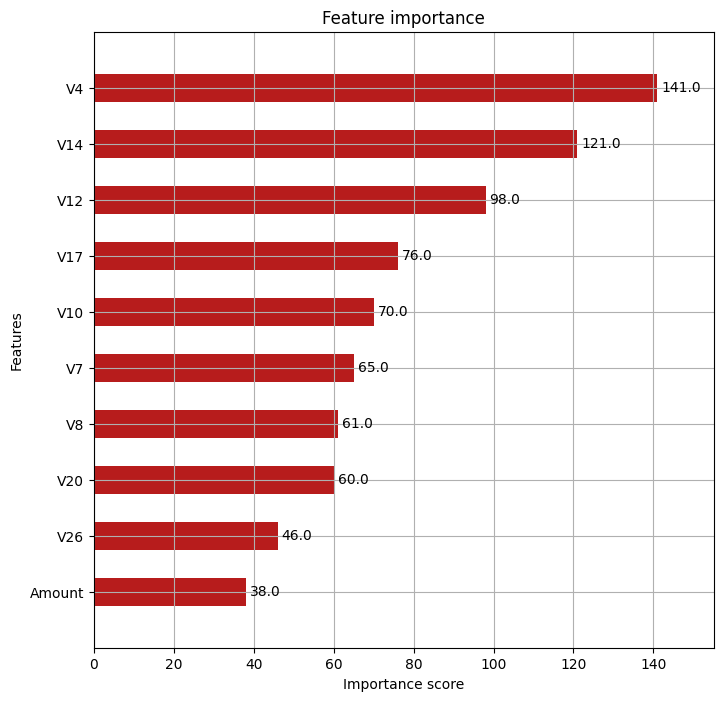

In [ ]:
# Showing Feature importance
xgbplot_feature_importance(xgb_model)

In [ ]:
score = xgb_model.get_fscore()
sorted_score = sorted(score.items(),key=operator.itemgetter(1), reverse=True)
sorted_cols = [i[0] for i in sorted_score] + ['Class']
print("sorted_cols: ", sorted_cols)

sorted_cols:  ['V4', 'V14', 'V12', 'V17', 'V10', 'V7', 'V8', 'V20', 'V26', 'Amount', 'V11', 'V28', 'V27', 'V3', 'V19', 'V21', 'V16', 'V5', 'V18', 'V2', 'V15', 'V1', 'V13', 'Time', 'V22', 'V6', 'V23', 'V24', 'V25', 'V9', 'Class']


In [ ]:
# Apply transformation to time column
credit_df["Time"] = credit_df["Time"].apply(lambda x: convert_time_of_day_to_hour(x))

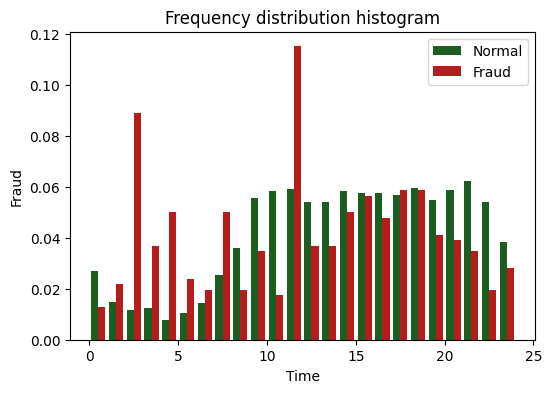

In [ ]:
# Frequency distribution histogram
plot_frequency_distribution(credit_df,"Time","Time","Fraud","Frequency distribution histogram")

<Figure size 600x400 with 0 Axes>

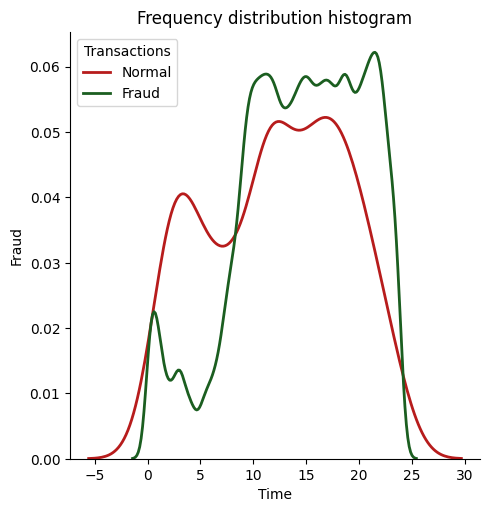

In [ ]:
kde_plot_frequency(credit_df,"Time","Time","Fraud","Frequency distribution histogram")

<Figure size 600x400 with 0 Axes>

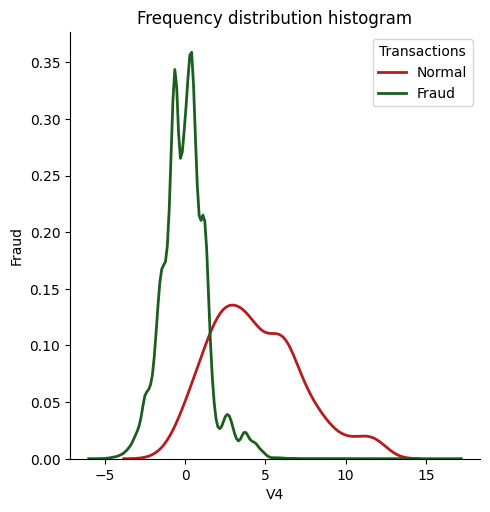

In [ ]:
kde_plot_frequency(credit_df,"V4","V4","Fraud","Frequency distribution histogram")

In [ ]:
# Show the statistical skewness of our dataset
credit_df.skew()

,0
Time,-0.499223
V1,-3.271779
V2,-4.734674
V3,-2.107315
V4,0.667689
V5,-2.410093
V6,1.832450
V7,3.031678
V8,-8.324049
V9,0.532278


In [ ]:
print("minimal_amount: ",credit_df['Amount'].min())
print("maximal_amount: ",credit_df['Amount'].max())
print("percentage_of_amount_equal_to_zeros: ",np.sum(credit_df['Amount'] ==0)/len(credit_df))

minimal_amount:  0.0
maximal_amount:  25691.16
percentage_of_amount_equal_to_zeros:  0.006350878061020735


<Axes: >

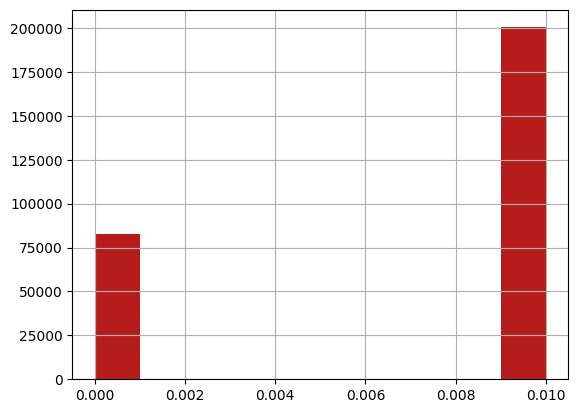

In [ ]:
# Frequency distribution of amount
credit_df['Amount'].mod(0.01).hist(color='#B71C1C')

In [ ]:
# Apply a logarithmic transformation to amount column
#df['log_amount'] = np.log1p(df['amount'])

### Scaling our dataset

In [ ]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,0.000278,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,0.000278,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,0.000556,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Scaling only Time and Amount column because v1 to v28 are already PCA-transformed and approximately standardized
scaler = StandardScaler()
credit_df["Time"] = scaler.fit_transform(credit_df[["Time"]])
credit_df["Amount"] = scaler.fit_transform(credit_df[["Amount"]])

In [ ]:
label_cols = ['Class']
data_cols = list(credit_df.columns[credit_df.columns != 'Class'])

### Initialization of our GAN

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

gan_model = BaseGAN(feature_dim=len(data_cols),latent_dim=128).to(device)

In [ ]:
# Initialize optimizer parametter for the generator and the discriminator
g_optimizer = optim.Adam(
    gan_model.generator.parameters(),
    lr=1e-4,
    betas=(0.0, 0.9)
)

c_optimizer = optim.Adam(
    gan_model.critic.parameters(),
    lr=1e-4,
    betas=(0.0, 0.9)
)

In [ ]:
fraud_df = credit_df[credit_df.Class == 1]
normal_df = credit_df[credit_df.Class == 0]
x_tensor = torch.FloatTensor(fraud_df[data_cols].values)
dataset = TensorDataset(x_tensor)

In [ ]:
train_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    drop_last=True
)

In [ ]:
epochs = 500
lambda_gp = 10
critic_iter = 5

In [ ]:
for real_batch in train_loader:
  print(real_batch[0].to(device).shape)
  break

torch.Size([64, 30])


In [ ]:
 # Train our GAN
gan_full_train_loop(gan_model,c_optimizer,epochs,lambda_gp,critic_iter,device,train_loader)

Epoch [1/500] Critic: -4.0675 Generator: -4.0494
Epoch [2/500] Critic: -3.2321 Generator: -0.8797
Epoch [3/500] Critic: -2.5613 Generator: 6.6586
Epoch [4/500] Critic: -3.3251 Generator: 11.4281
Epoch [5/500] Critic: -4.7940 Generator: -1.8056
Epoch [6/500] Critic: -4.0482 Generator: -9.2112
Epoch [7/500] Critic: -3.8415 Generator: 8.5648
Epoch [8/500] Critic: -3.7656 Generator: 9.4358
Epoch [9/500] Critic: -5.6315 Generator: 4.1819
Epoch [10/500] Critic: -4.4529 Generator: -9.0854
Epoch [11/500] Critic: -3.8772 Generator: 6.0273
Epoch [12/500] Critic: -6.7661 Generator: -11.1607
Epoch [13/500] Critic: -7.7033 Generator: -12.7141
Epoch [14/500] Critic: -5.2402 Generator: -0.5471
Epoch [15/500] Critic: -4.3000 Generator: -8.2674
Epoch [16/500] Critic: -4.3710 Generator: -6.4428
Epoch [17/500] Critic: -3.7839 Generator: 5.8799
Epoch [18/500] Critic: -3.4565 Generator: 11.9187
Epoch [19/500] Critic: -3.6071 Generator: 1.1105
Epoch [20/500] Critic: -4.6889 Generator: -5.5705
Epoch [21/500]

In [ ]:
gan_model.eval()

with torch.no_grad():
  z = gan_model.sample_noise(2000,device)
  synthetic_fraud = gan_model.generate(z)
  synthetic_fraud = (synthetic_fraud.cpu().numpy())


In [ ]:
synthetic_fraud_df = pd.DataFrame(synthetic_fraud,columns=data_cols)

In [ ]:
normal_df["Source"] = "Normal"
normal_df["Class"] = 0
fraud_df["Source"] = "Fraud"
fraud_df["Class"] = 1
synthetic_fraud_df["Source"] = "Synthetic Fraud"
synthetic_fraud_df["Class"] = 2

/tmp/ipykernel_19158/3451209637.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_df["Source"] = "Normal"
/tmp/ipykernel_19158/3451209637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  normal_df["Class"] = 0
/tmp/ipykernel_19158/3451209637.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

In [ ]:
combined_df = pd.concat([normal_df.sample(2000, random_state=42),fraud_df,synthetic_fraud_df], ignore_index=True)

In [ ]:
synthetic_fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Source,Class
0,-0.436359,1.580614,1.476846,-4.002521,4.147840,0.157342,-0.613846,-1.307106,0.774654,-1.063079,...,-0.151481,0.215053,0.173493,-0.231399,0.077382,0.360608,0.287415,-0.563988,Synthetic Fraud,2
1,-1.765240,-1.062950,4.898958,-6.010368,5.071975,0.386504,-2.591764,-2.429331,1.104622,-2.725437,...,-0.777097,-0.391586,-0.274725,0.784595,0.249087,0.813276,0.440025,-0.512230,Synthetic Fraud,2
2,0.983979,0.122509,2.414532,-4.111542,5.376014,-0.113924,-1.188151,-2.472929,0.374803,-2.044757,...,-0.411161,0.245977,-0.167710,-0.173783,-0.112660,0.533404,0.414515,-0.545750,Synthetic Fraud,2
3,-2.041460,-2.195854,5.966220,-9.549071,7.300415,-1.912943,-2.546346,-5.861536,2.706190,-3.731924,...,-0.168890,0.281273,-0.825309,-0.265544,0.354958,0.900465,0.526740,-0.506940,Synthetic Fraud,2
4,0.451638,0.505045,1.016361,-2.468377,3.273772,4.359640,-1.230894,-2.074531,-0.765988,-1.452878,...,1.829756,-2.464033,-0.739357,-0.395759,0.497734,0.152350,0.249233,-0.697012,Synthetic Fraud,2


In [ ]:
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Source
541,-2.467790,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,-0.353337,1,Fraud
623,-2.464653,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.757873,1,Fraud
4920,-2.275040,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,0.604210,1,Fraud
6108,-2.155094,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,-0.117872,1,Fraud
6329,-2.129764,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,-0.349347,1,Fraud


In [ ]:
x_combined = combined_df[data_cols]
y_combined = combined_df["Source"]

In [ ]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

In [ ]:
X_tsne = tsne.fit_transform(x_combined)

### Display Data distribution

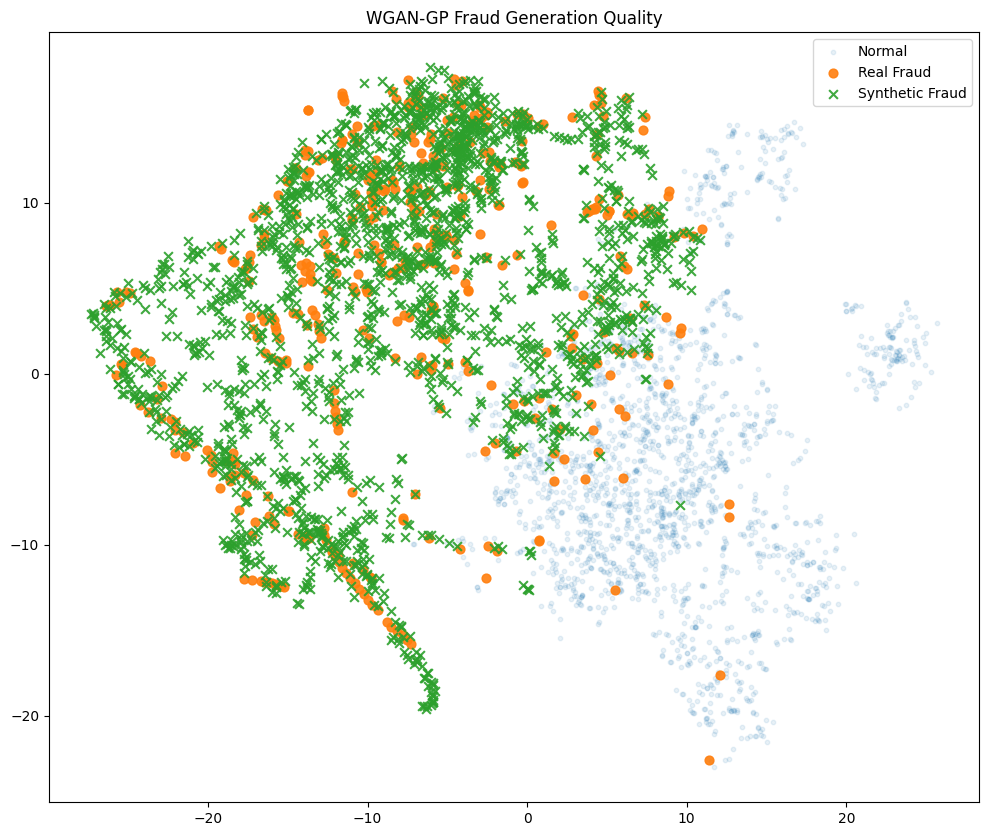

In [ ]:
plt.figure(figsize=(12,10))

normal_idx = y_combined == "Normal"
fraud_idx = y_combined == "Fraud"
synthetic_idx = y_combined == "Synthetic Fraud"

plt.scatter(
    X_tsne[normal_idx,0],
    X_tsne[normal_idx,1],
    alpha=0.1,
    s=10,
    label="Normal"
)

plt.scatter(
    X_tsne[fraud_idx,0],
    X_tsne[fraud_idx,1],
    alpha=0.9,
    s=40,
    label="Real Fraud"
)

plt.scatter(
    X_tsne[synthetic_idx,0],
    X_tsne[synthetic_idx,1],
    alpha=0.9,
    s=40,
    marker="x",
    label="Synthetic Fraud"
)

plt.legend()
plt.title("WGAN-GP Fraud Generation Quality")
plt.show()

In [ ]:
label_cols = ['Class']
data_cols = list(credit_df.columns[credit_df.columns != 'Class'])

In [ ]:
fraud_df = credit_df[credit_df.Class == 1]
normal_df = credit_df[credit_df.Class == 0]

### SMOTE (moderate oversampling)

- Step 1: Moderate SMOTE
- Step 2: Train CTGAN
- Step 3: Generate More Fraud Samples

In [ ]:
# Use Smote for moderate oversampling by increasing fraud samples -> 2000

smote = SMOTE(
    sampling_strategy = 2000/len(credit_df[credit_df["Class"] ==0]),
    random_state=42
)

In [ ]:
x_smote,y_smote = smote.fit_resample(credit_df[data_cols],credit_df["Class"])

In [ ]:
fraud_smote = pd.DataFrame(x_smote[y_smote == 1],columns=credit_df.columns)

In [ ]:
fraud_smote["Class"] = 1

In [ ]:
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,-2.467790,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,-0.353337,1
623,-2.464653,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1.757873,1
4920,-2.275040,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,0.604210,1
6108,-2.155094,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,-0.117872,1
6329,-2.129764,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,-0.349347,1


In [ ]:
fraud_df.shape

(460, 31)

In [ ]:
fraud_smote.iloc[460:].head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
282953,-0.119338,1.258734,0.494097,-0.330627,1.121797,0.380359,-0.246934,0.080130,-0.030541,0.069115,...,-0.068839,-0.122712,-0.172436,-0.781858,0.678994,-0.256681,0.042200,0.034584,-0.349142,1
282954,-0.356570,-2.530597,3.546231,-4.100249,5.297583,-2.587591,-0.137728,-4.412882,-0.137736,-2.814767,...,2.262493,-0.126025,0.318200,-0.213838,-0.279621,0.270769,0.854120,0.248024,0.054548,1
282955,0.874483,1.130034,1.127167,-1.418236,2.012285,0.638135,-1.090895,0.208724,0.059110,0.030063,...,-0.359616,-0.863366,-0.150902,-0.129290,0.650549,-0.349274,0.075074,0.113442,-0.349347,1
282956,0.803018,1.432920,-0.689993,-0.490437,-0.628876,-0.608484,-0.343584,-0.627975,0.019599,-0.639587,...,0.048607,-0.027497,-0.103859,-0.192070,0.330556,-0.248805,0.003934,0.023068,-0.036187,1
282957,-1.164167,0.306943,0.976203,-1.556635,1.919378,-1.887838,-1.171260,-2.799180,0.637571,-0.700987,...,0.594645,0.345354,-0.059397,0.255565,0.328273,0.605157,0.566846,0.306204,-0.255355,1


In [ ]:
report = QualityReport()
metadata = {
    'columns': {col: {'sdtype': 'numerical'} for col in data_cols}
}

In [ ]:
report.generate(
    real_data=fraud_df[data_cols],
    synthetic_data=fraud_smote.iloc[460:][data_cols],
    metadata=metadata
)


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 30/30 [00:00<00:00, 187.17it/s]|
Column Shapes Score: 95.37%

(2/2) Evaluating Column Pair Trends: |██████████| 435/435 [00:03<00:00, 117.89it/s]|
Column Pair Trends Score: 99.25%

Overall Score (Average): 97.31%



In [ ]:
details = report.get_details("Column Shapes")
print(details.sort_values("Score"))

    Column        Metric     Score
29  Amount  KSComplement  0.897939
0     Time  KSComplement  0.927470
13     V13  KSComplement  0.935517
26     V26  KSComplement  0.939130
24     V24  KSComplement  0.946556
25     V25  KSComplement  0.947995
20     V20  KSComplement  0.951553
21     V21  KSComplement  0.951637
23     V23  KSComplement  0.952936
19     V19  KSComplement  0.952964
22     V22  KSComplement  0.953755
28     V28  KSComplement  0.954037
5       V5  KSComplement  0.955392
6       V6  KSComplement  0.955562
15     V15  KSComplement  0.956550
11     V11  KSComplement  0.957764
27     V27  KSComplement  0.958018
4       V4  KSComplement  0.958272
7       V7  KSComplement  0.959119
12     V12  KSComplement  0.959147
1       V1  KSComplement  0.960136
9       V9  KSComplement  0.961265
16     V16  KSComplement  0.961293
10     V10  KSComplement  0.961858
2       V2  KSComplement  0.964596
18     V18  KSComplement  0.965048
14     V14  KSComplement  0.965669
3       V3  KSComple

In [ ]:
# Testing CTGAN (Conditional Tabular Generative Adversarial Network) for tabular data

ctgan_model = CTGAN(
    embedding_dim=128,
    generator_dim=(256, 256),
    discriminator_dim=(256, 256),
    batch_size=60,
    epochs=3000,
    verbose=True)



In [ ]:
ctgan_model.fit(fraud_smote[data_cols])

Gen. (-00.32) | Discrim. (-00.86): 100%|██████████| 3000/3000 [51:37<00:00,  1.03s/it]


In [ ]:
n_fraud = len(fraud_smote[fraud_smote["Class"] == 1])
n_normal = len(credit_df[credit_df["Class"] == 0])

needed = n_normal - n_fraud

print("Synthetic samples needed:", needed)

Synthetic samples needed: 280493


In [ ]:
synthetic_fraud_df = ctgan_model.sample(needed)

In [ ]:
synthetic_fraud_df.shape

(280493, 30)

In [ ]:
synthetic_fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.681574,2.031440,0.178274,-1.138892,1.029498,-0.862138,2.698622,1.802337,-4.359328,-1.084394,...,-0.087932,0.798205,0.924593,-0.178299,0.730645,0.188708,-0.095902,-0.340763,-0.119758,-0.360145
1,0.373181,-1.414737,3.075613,-3.892949,2.738089,0.404504,-0.124111,-1.050037,0.293333,-0.213915,...,0.002600,0.949962,1.278103,0.027117,-0.232200,0.222554,0.083849,0.621341,-0.000506,-0.124681
2,0.787020,-0.226518,1.977421,-3.834578,3.441591,2.307960,-1.360874,-3.575923,2.473720,-1.815747,...,-0.441973,1.455820,-0.423071,-0.082844,-0.555833,-0.022375,-0.019691,0.430486,-0.150458,-0.418219
3,0.183344,0.808792,0.811436,-4.378499,3.693104,6.817082,-1.734976,-0.400692,0.367827,-2.147911,...,-0.152536,0.287967,-0.197857,-1.729951,-1.141309,0.687150,0.027692,1.330350,0.103857,-0.370070
4,0.711009,1.517047,2.279796,-8.556390,4.163407,4.828563,-1.519124,-3.945759,0.979186,-4.201078,...,0.059617,0.359238,-1.064717,-0.331063,-0.409935,-0.134996,0.046772,0.620046,0.108444,-0.335678


In [ ]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-2.487084,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.243788,0
1,-2.487084,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342602,0
2,-2.487036,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.157874,0
3,-2.487036,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139544,0
4,-2.486989,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.074011,0


### Estimate the quality of the the data that has been generated

In [ ]:
report = QualityReport()

In [ ]:
metadata = {
    'columns': {col: {'sdtype': 'numerical'} for col in data_cols}
}

report.generate(
    real_data=fraud_df[data_cols],
    synthetic_data=synthetic_fraud_df,
    metadata=metadata
)



Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 30/30 [00:00<00:00, 61.64it/s]|
Column Shapes Score: 91.73%

(2/2) Evaluating Column Pair Trends: |██████████| 435/435 [00:12<00:00, 33.71it/s]|
Column Pair Trends Score: 91.89%

Overall Score (Average): 91.81%



In [ ]:
details = report.get_details("Column Shapes")
print(details.sort_values("Score"))

    Column        Metric     Score
29  Amount  KSComplement  0.704010
17     V17  KSComplement  0.881962
14     V14  KSComplement  0.887323
0     Time  KSComplement  0.892240
27     V27  KSComplement  0.893012
21     V21  KSComplement  0.899470
24     V24  KSComplement  0.900691
19     V19  KSComplement  0.904483
16     V16  KSComplement  0.904863
2       V2  KSComplement  0.908971
11     V11  KSComplement  0.909122
28     V28  KSComplement  0.912699
12     V12  KSComplement  0.916190
15     V15  KSComplement  0.917763
5       V5  KSComplement  0.919401
18     V18  KSComplement  0.921540
25     V25  KSComplement  0.922300
22     V22  KSComplement  0.924973
26     V26  KSComplement  0.936963
7       V7  KSComplement  0.938124
20     V20  KSComplement  0.938336
4       V4  KSComplement  0.942192
23     V23  KSComplement  0.942486
8       V8  KSComplement  0.943400
9       V9  KSComplement  0.945977
10     V10  KSComplement  0.955471
3       V3  KSComplement  0.957604
1       V1  KSComple

### Display Data distribution

In [ ]:
normal_df["Source"] = "Normal"
normal_df["Class"] = 0
fraud_df["Source"] = "Fraud"
fraud_df["Class"] = 1
synthetic_fraud_df["Source"] = "Synthetic Fraud"
synthetic_fraud_df["Class"] = 1

In [ ]:
combined_df = pd.concat([normal_df.sample(2000, random_state=42),fraud_df,synthetic_fraud_df.sample(2000,random_state=42)], ignore_index=True)

In [ ]:
x_combined = combined_df[data_cols]
y_combined = combined_df["Source"]

In [ ]:
tsne = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

In [ ]:
x_tsne = tsne.fit_transform(x_combined)

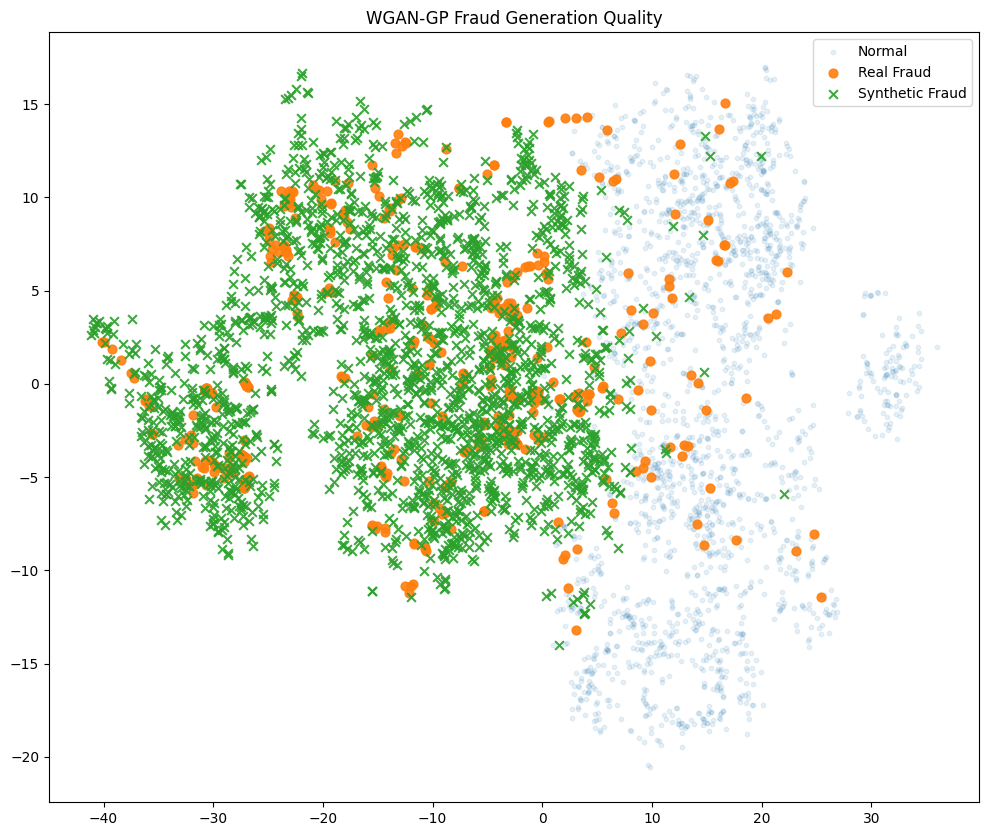

In [ ]:
plot_tsne_visualization(y_combined,x_tsne,figsize=(12,10))

#  Merge data to create an augmented dataset

- Original fraud
- Normal transactions
- Synthetic fraud

In [ ]:
normal_df = normal_df.drop(columns=["Source"])
fraud_df = fraud_df.drop(columns=["Source"])
synthetic_fraud_df = synthetic_fraud_df.drop(columns=["Source"])

In [ ]:
augmented_credit_df = pd.concat([normal_df,fraud_df,synthetic_fraud_df],ignore_index=True)

In [ ]:
augmented_credit_df.shape

(563446, 31)

In [ ]:
augmented_credit_df

In [ ]:
augmented_credit_df.groupby("Class")["Class"].count()

,Class
Class,
0,282493
1,280953


In [ ]:
normal_duplicates = sum(augmented_credit_df.loc[augmented_credit_df.Class == 0].duplicated())
fraude_duplicates = sum(augmented_credit_df.loc[augmented_credit_df.Class == 1].duplicated())
total_duplicates = normal_duplicates + fraude_duplicates

print("Normal_duplicates: ",normal_duplicates)
print("Fraud_duplicates: ",fraude_duplicates)
print("total_duplicates: ",total_duplicates)
print("Fraction_duplicates: ",total_duplicates/len(augmented_credit_df))

Normal_duplicates:  0
Fraud_duplicates:  0
total_duplicates:  0
Fraction_duplicates:  0.0


In [ ]:
augmented_credit_df.to_csv("/content/augmented_creditcard.csv",index=False)

In [ ]:
x = credit_df.iloc[:,:-1]
y = credit_df["Class"]

x_train_temp,x_test,y_train_temp,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train,x_val,y_train,y_val = train_test_split(x_train_temp,y_train_temp,test_size=0.1,stratify=y_train_temp,random_state=42)